#  Amazon E-Commerce Sales Analysis
## Notebook 3 - Exploratory Data Analysis (EDA)

*Objective:* Explore the clean dataset to find patterns, 
trends, and business insights across categories, 
states, revenue, and customer behaviour.

*Input:* amazon_cleaned.csv (105,080 rows, 21 columns)  

---

In [2]:
# ==========================================================
# STEP 1: IMPORT LIBRARIES AND LOAD CLEAN DATA
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# set visual style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

# load the cleaned dataset
df = pd.read_csv('amazon_cleaned.csv')
print(f"clean data loaded: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"\nColumns: {list(df.columns)}")

clean data loaded: 105080 rows, 21 columns

Columns: ['index', 'Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel ', 'ship-service-level', 'Style', 'SKU', 'Category', 'Size', 'Qty', 'currency', 'Amount', 'ship-city', 'ship-state', 'ship-country', 'B2B', 'Month', 'Month_name', 'Year']


========== REVENUE BY CATEGORY ==========

Top category: Set
Top revenue: ₹34,728,149


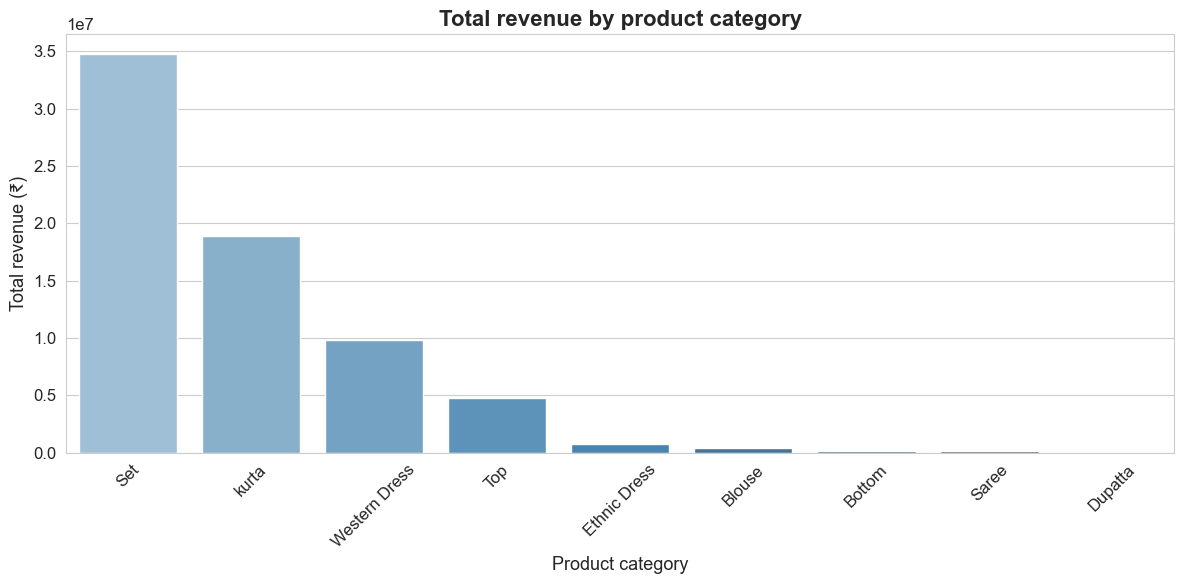

Chart Saved!


In [28]:
# ==========================================================
# ANALYSIS 1: REVENUE BY CATEGORY
# ==========================================================

#calculate total revenue by category
category_revenue = df.groupby('Category')['Amount'].sum().reset_index()
category_revenue.columns = ['Category', 'total_revenue']
category_revenue = category_revenue.sort_values('total_revenue', ascending=False)

print("========== REVENUE BY CATEGORY ==========")
print(f"\nTop category: {category_revenue.iloc[0]['Category']}")
print(f"Top revenue: ₹{category_revenue.iloc[0]['total_revenue']:,.0f}")

# create bar chart
plt.figure(figsize=(12, 6))
sns.barplot(data=category_revenue, x='Category', y='total_revenue', hue='Category', legend=False, palette='Blues_d')
plt.title('Total revenue by product category', fontsize=16, fontweight='bold')
plt.xlabel('Product category', fontsize=13)
plt.ylabel('Total revenue (₹)', fontsize=13)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('Chart1_revenue_by_category.png', dpi=150)
plt.show()
print("Chart Saved!")

========== MONTHLY REVENUE TREND ==========
  Month_name  total_revenue
0      March        94183.0
1      April     25663582.0
2        May     23460112.0
3       June     20430404.0


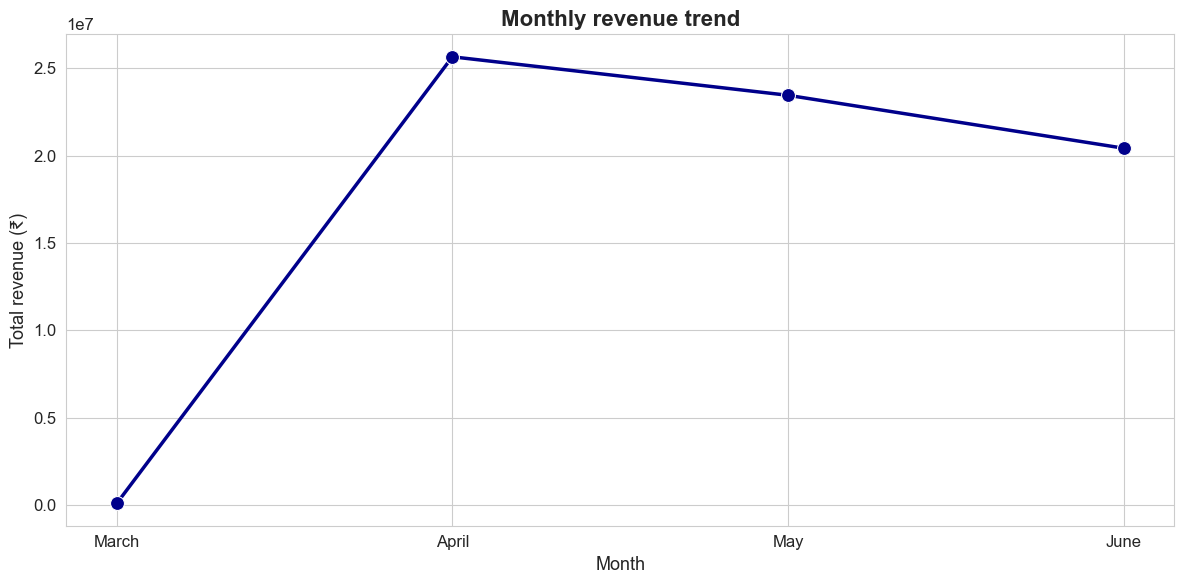

Chart Saved!


In [30]:
# ==========================================================
# ANALYSIS 2: MONTHY REVENUE TREND
# ==========================================================

monthly_revenue = df.groupby(['Month', 'Month_name'])['Amount'].sum().reset_index()
monthly_revenue.columns = ['Month', 'Month_name', 'total_revenue']
monthly_revenue = monthly_revenue.sort_values('Month')

print("========== MONTHLY REVENUE TREND ==========")
print(monthly_revenue[['Month_name', 'total_revenue']])   

#line chart
plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_revenue, x='Month_name', y='total_revenue', marker='o', linewidth=2.5, color='darkblue', markersize=10)
plt.title('Monthly revenue trend', fontsize=16, fontweight='bold')
plt.xlabel('Month', fontsize=13)
plt.ylabel('Total revenue (₹)', fontsize=13)
plt.tight_layout()
plt.savefig('Chart2_monthly_revenue_trend.png', dpi=150)
plt.show()
print("Chart Saved!")

### Key Insight — Monthly Revenue
- *April* is the highest revenue month — ₹2.57 Crore
- Revenue declined *8.5%* from April to May
- Revenue declined further *13%* from May to June
- *Recommendation:* Investigate root cause of 
declining trend — competition, seasonality, 
or product availability issues

========== REVENUE BY STATE ==========
             State  total_revenue
27     MAHARASHTRA     11955492.0
22       KARNATAKA      9436223.0
55       TELANGANA      6123778.0
57   UTTAR PRADESH      5968983.0
54      TAMIL NADU      5812085.0
13           DELHI      3806844.0
23          KERALA      3301081.0
59     WEST BENGAL      3096107.0
1   ANDHRA PRADESH      2796932.0
18         HARYANA      2588923.0


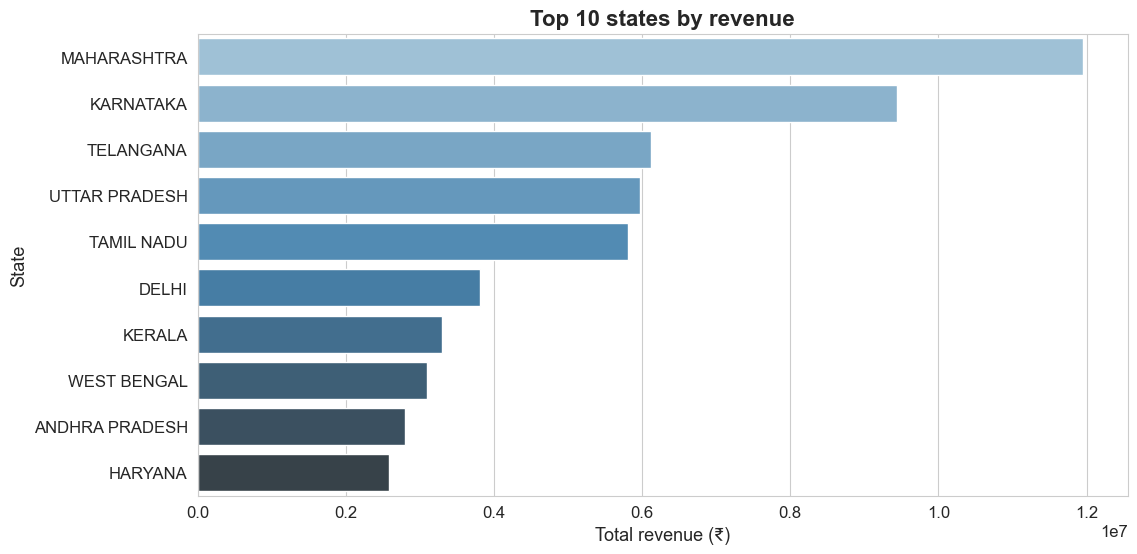

chart saved!


In [34]:
# ==========================================================
# ANALYSIS 3: REVENUE BY STATE
# ==========================================================

state_revenue = df.groupby('ship-state')['Amount'].sum().reset_index()
state_revenue.columns = ['State', 'total_revenue']
state_revenue = state_revenue.sort_values('total_revenue', ascending=False)
top10_states = state_revenue.head(10)

print("========== REVENUE BY STATE ==========")
print(top10_states)

#horizontal bar chart
plt.figure(figsize = (12, 6))
sns.barplot(data=top10_states, y='State', x='total_revenue', hue='State', legend=False, palette='Blues_d')
plt.title('Top 10 states by revenue', fontsize=16, fontweight='bold')
plt.xlabel('Total revenue (₹)', fontsize=13)
plt.ylabel('State', fontsize=13)
plt.savefig('chart3_revenue_by_state.png')
plt.show()
print("chart saved!")


### Key Insight — Revenue by State
- *Maharashtra* is #1 state — ₹1.19 Crore
- *Top 5 states* contribute ~65% of total revenue
- *South & West India* dominates sales
- *Recommendation:* Prioritise marketing 
  spend in Maharashtra, Karnataka, and 
  Telangana for maximum ROI

##  Analysis 4: Order Count by Category
*Business Question:* Which category has the 
highest number of orders — not just revenue?

========== ORDER COUNT BY CATEGORY ==========
        Category  order_count
5            Set        40654
8          kurta        40596
7  Western Dress        12639
6            Top         8961
3   Ethnic Dress          958
0         Blouse          768
1         Bottom          360
4          Saree          141
2        Dupatta            3


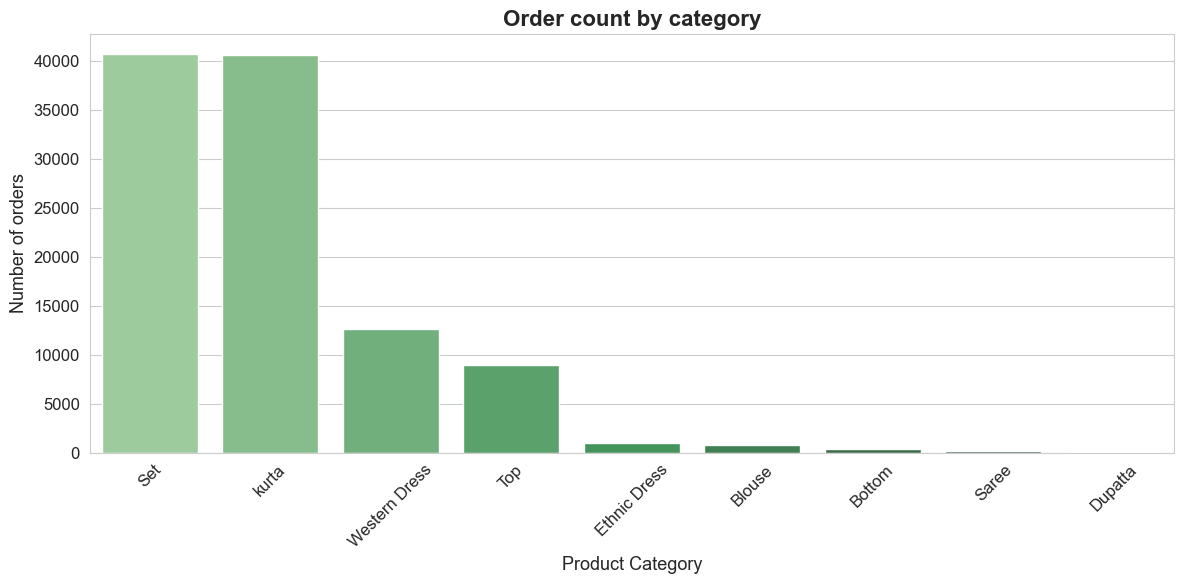

Chart saved!


In [7]:
# ==========================================================
# ANALYSIS 4: ORDER COUNT BY CATEGORY
# ==========================================================

category_order = df.groupby('Category')['Order ID'].count().reset_index()
category_order.columns = ['Category', 'order_count']
category_order =  category_order.sort_values('order_count', ascending=False)

print("========== ORDER COUNT BY CATEGORY ==========")
print(category_order)

#bar chart
plt.figure(figsize=(12, 6))
sns.barplot(data=category_order, x='Category', y='order_count', hue='Category', legend=False, palette='Greens_d')
plt.title('Order count by category', fontsize=16, fontweight='bold')
plt.xlabel('Product Category', fontsize=13)
plt.ylabel('Number of orders', fontsize=13)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('chart4_order_by_category.png', dpi=150)
plt.show()
print('Chart saved!')

### Key Insight — Orders by Category
- *Set and Kurta* have almost equal orders 
  (~40,600 each) — neck to neck competition!
- But *Set generates double the revenue* 
  of Kurta — higher price per item
- *Set is the star product* — most ordered 
  AND most revenue generating
- *Recommendation:* Prioritise Set category 
  inventory and focus promotions here

In [17]:
# ==========================================================
# ANALYSIS 4B: ORDER VALUE BY CATEGORY
# ==========================================================

avg_order = df.groupby('Category')['Amount'].mean().reset_index()
avg_order.columns = ['Category', 'avg_order_value']
avg_order = avg_order.sort_values('avg_order_value', ascending=False)

print("========== AVERAGE ORDER VALUE BY CATEGORY ==========")
print(avg_order.round(2))

========== AVERAGE ORDER VALUE BY CATEGORY ==========
        Category  avg_order_value
5            Set           854.24
4          Saree           806.35
7  Western Dress           777.59
3   Ethnic Dress           746.71
6            Top           535.07
0         Blouse           533.20
8          kurta           466.18
1         Bottom           369.09
2        Dupatta           305.00


========== Top 10 cities by Order Count ==========
           city  order_count
708   BENGALURU         9495
2661  HYDERABAD         6630
4383     MUMBAI         5148
4923  NEW DELHI         4748
1334    CHENNAI         4488
5654       PUNE         3201
3408    KOLKATA         1961
2394   GURUGRAM         1574
6956      THANE         1385
4995      NOIDA         1164


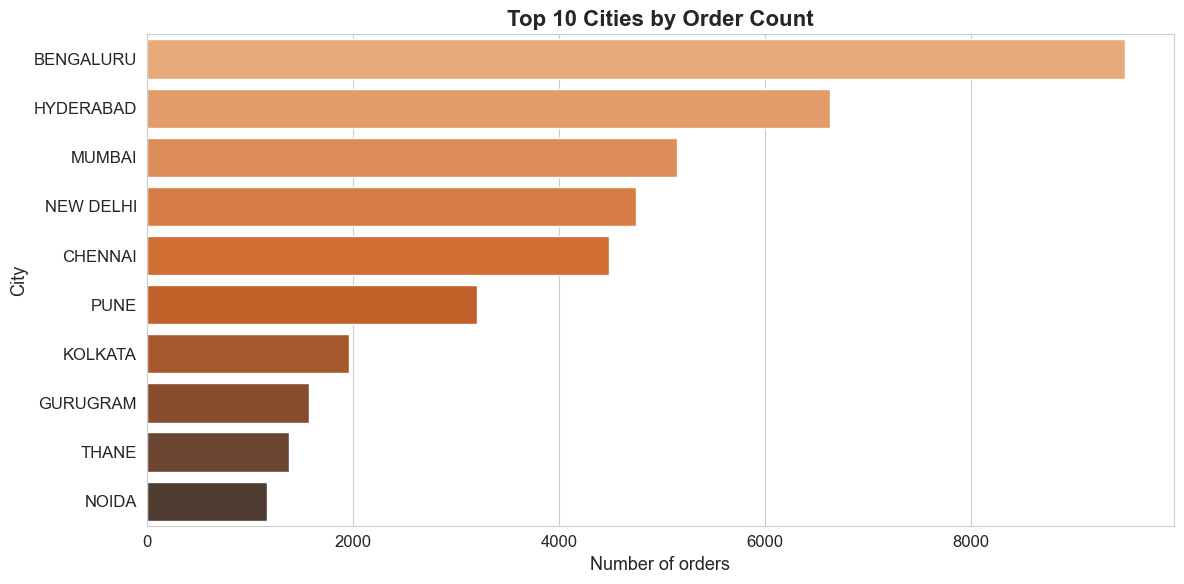

Chart saved!


In [35]:
# ==========================================================
# ANALYSIS 5: TOP 10 CITIES BY ORDER COUNT
# ==========================================================

city_orders = df.groupby('ship-city')['Order ID'].count().reset_index()
city_orders.columns = ['city', 'order_count']
city_orders = city_orders.sort_values('order_count', ascending=False)
top10_cities = city_orders.head(10)

print("========== Top 10 cities by Order Count ==========")
print(top10_cities)

#bar plot
plt.figure(figsize=(12, 6))
sns.barplot(data=top10_cities, y='city', x='order_count', hue='city', legend=False, palette='Oranges_d')
plt.title('Top 10 Cities by Order Count', fontsize=16, fontweight='bold')
plt.xlabel('Number of orders', fontsize=13)
plt.ylabel('City', fontsize=13)
plt.tight_layout()
plt.savefig('chart5_top_cities_by_order_count.png', dpi=150)
plt.show()
print("Chart saved!")

##  Analysis 6: Orders by Size
*Business Question:* Which clothing size is 
most popular among Amazon India customers?

========== ORDER BY SIZE ==========
    index  Size  Order count
0       6     M        18297
1       5     L        17959
2       8    XL        17085
3      10   XXL        14884
4       7     S        13738
5       0   3XL        12399
6       9    XS         8916
7       3   6XL          646
8       2   5XL          473
9       1   4XL          364
10      4  Free          319


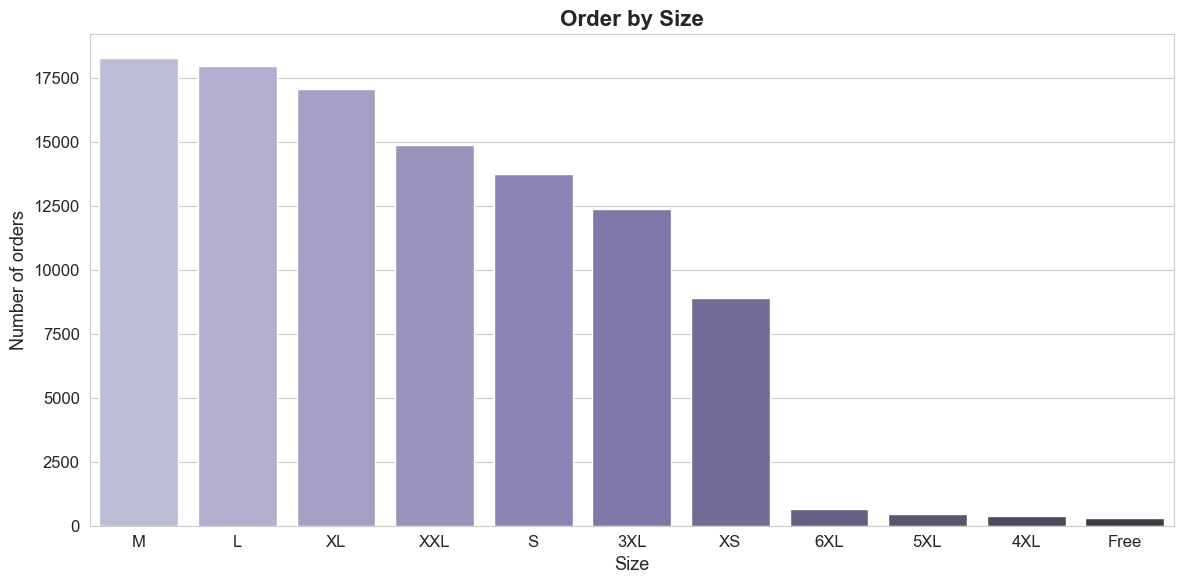

Chart Saved!


In [37]:
# ==========================================================
# ANALYSIS 6: ORDERS BY SIZE
# ==========================================================

size_orders = df.groupby('Size')['Order ID'].count().reset_index()
size_orders.columns = ['Size', 'Order count']
size_orders = size_orders.sort_values('Order count', ascending=False).reset_index(drop=False)

print("========== ORDER BY SIZE ==========")
print(size_orders)

#bar chart
plt.figure(figsize = (12, 6))
sns.barplot(data=size_orders, x='Size', y='Order count', hue='Size', legend=False, palette='Purples_d')
plt.title('Order by Size', fontsize=16, fontweight='bold')
plt.xlabel('Size', fontsize=13)
plt.ylabel('Number of orders', fontsize=13)
plt.tight_layout()
plt.savefig('Chart6_order_by_size.png', dpi=150)
plt.show()
print("Chart Saved!")

### Key Insight — Size Analysis
- *M, L, XL* are top 3 sizes — 50.7% of orders
- *Medium* is the most popular size — 18,297 orders
- *Plus sizes* (4XL-6XL) are underserved — only 2%
- *Recommendation:* Focus inventory on M, L, XL
  and explore plus-size market as growth opportunity

## Analysis 7: B2B vs B2C Orders
*Business Question:* What percentage of Amazon 
orders are from businesses vs individual customers?

========== B2B VS B2C ==========
    customer_type  order_count  percentage
0  B2C (Consumer)       104296        99.3
1  B2B (Business)          784         0.7


ValueError: unsupported format character ',' (0x2c) at index 2

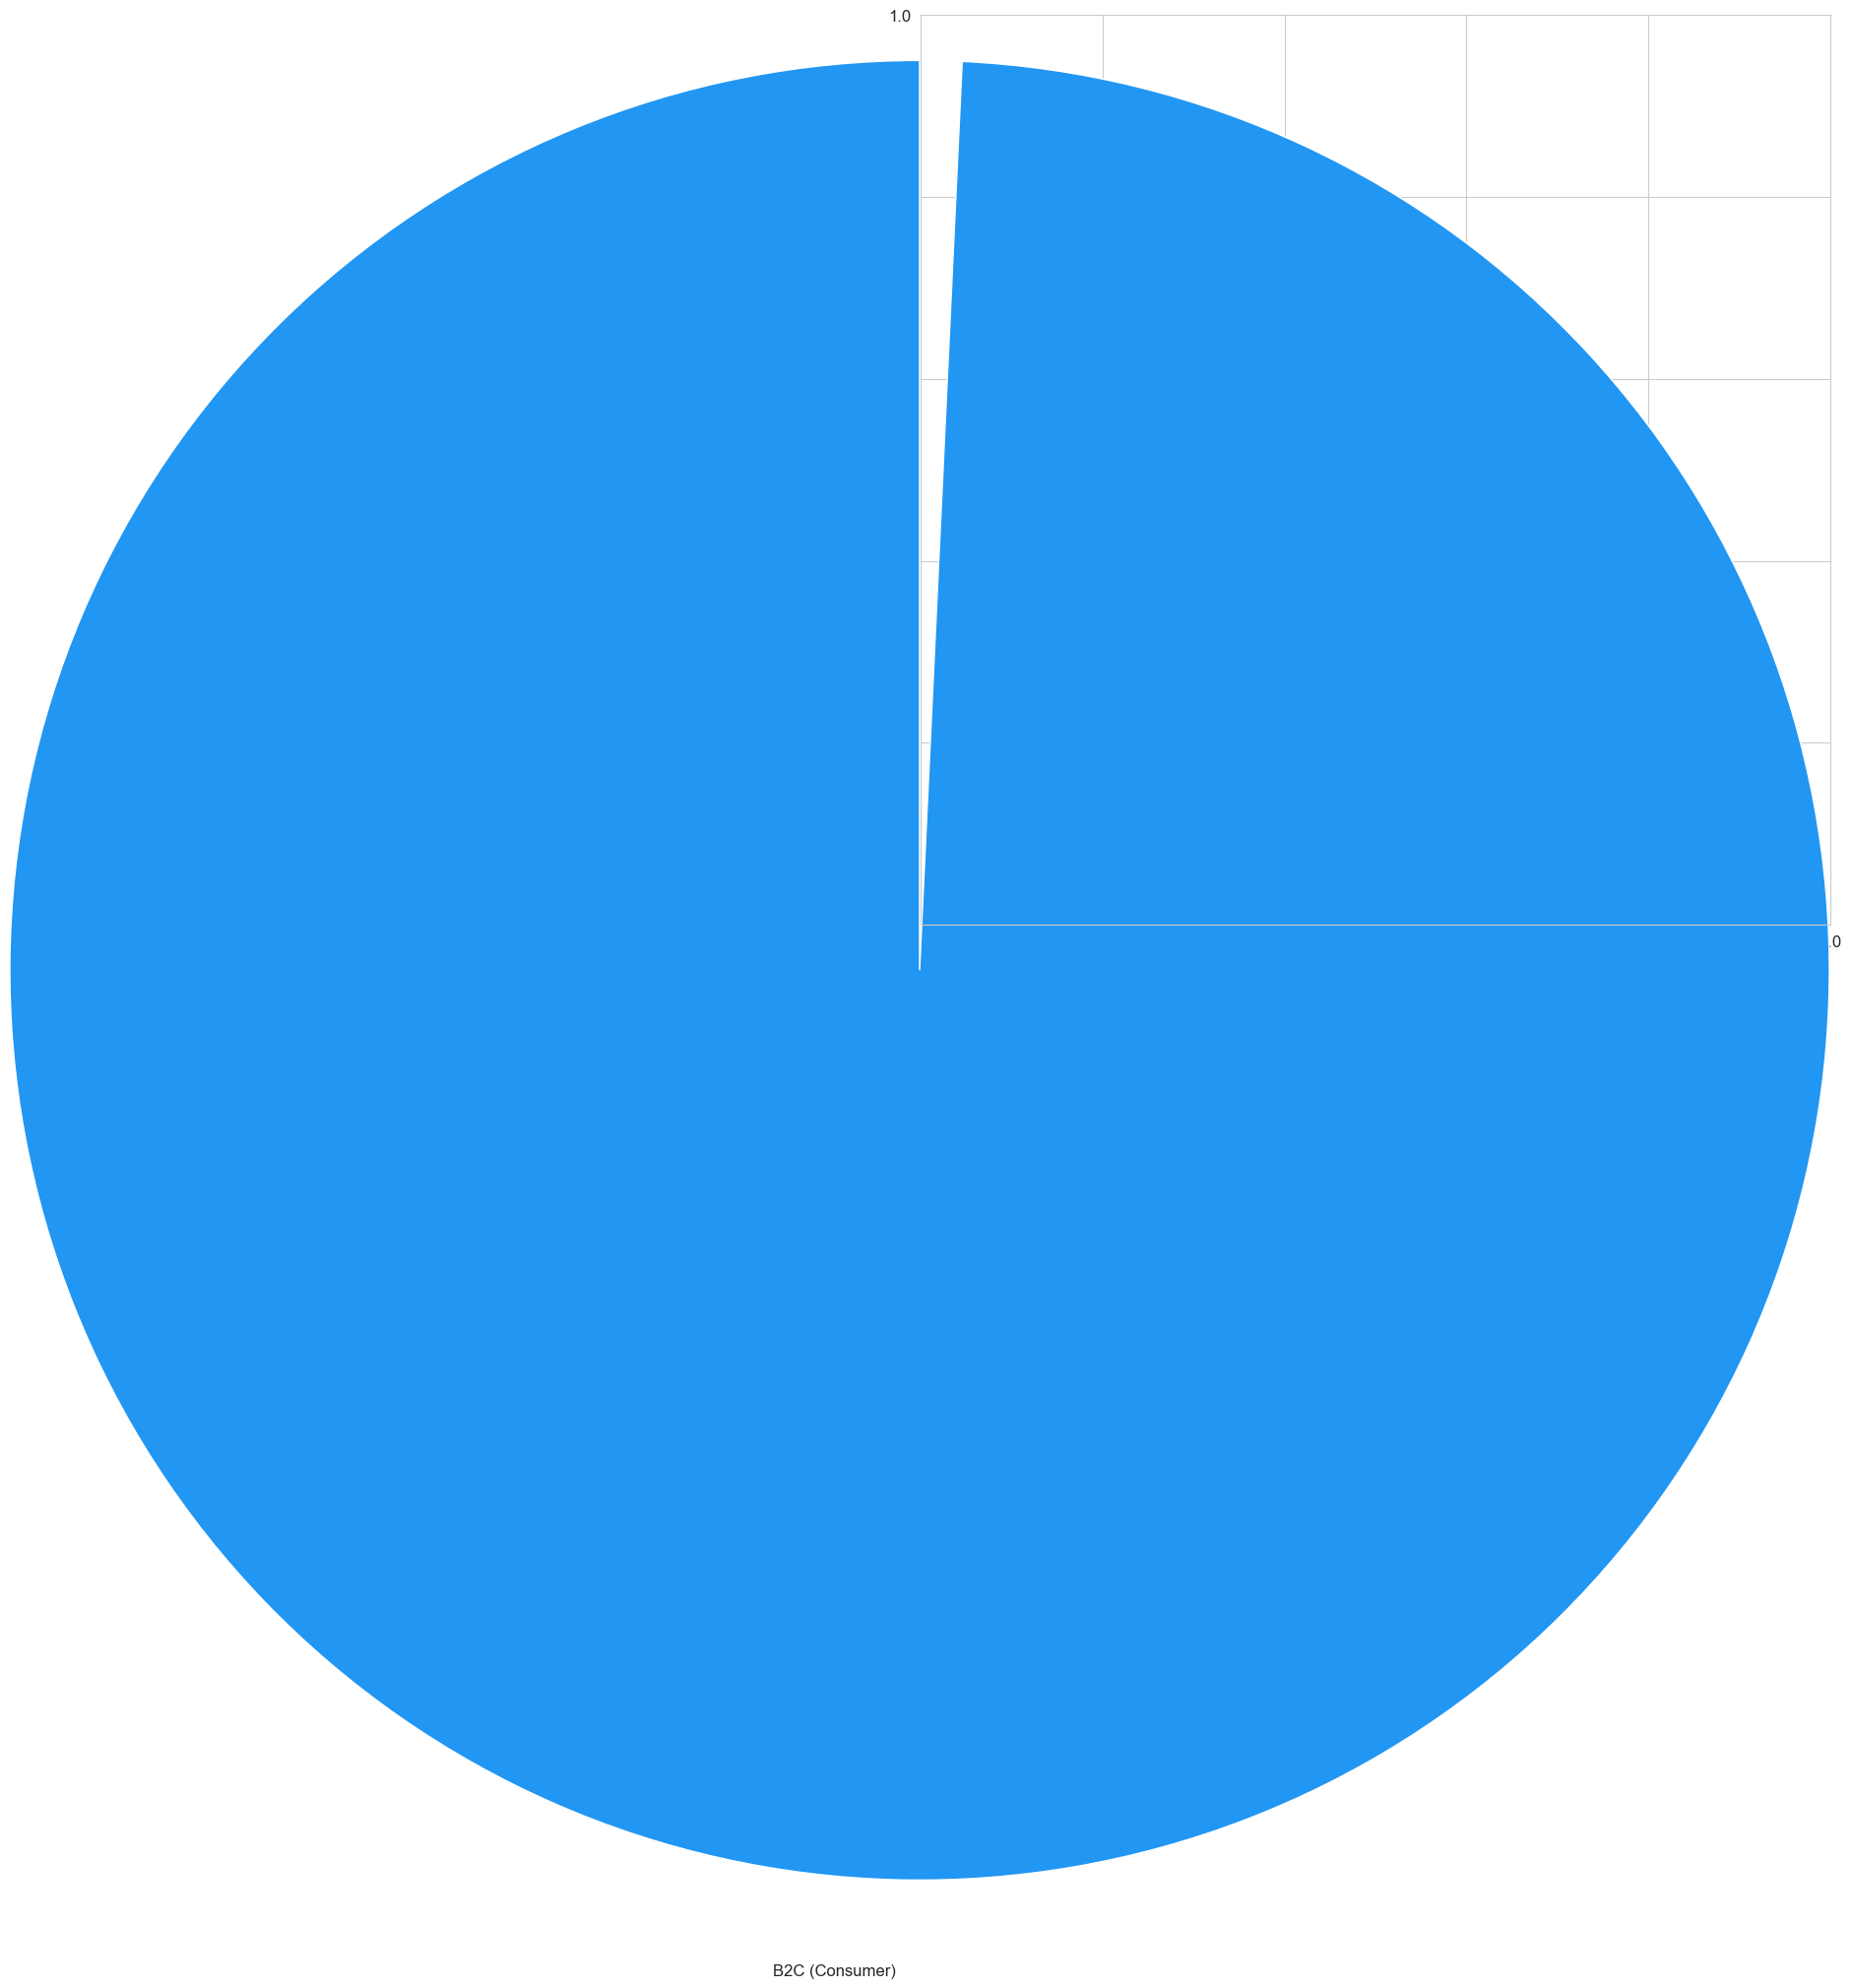

In [ ]:
# ==========================================================
# ANALYSIS 7: B2B VS B2C
# ==========================================================

b2b_count = df['B2B'].value_counts().reset_index()
b2b_count.columns = ['customer_type', 'order_count']
b2b_count['customer_type'] = b2b_count['customer_type'].map({True: 'B2B (Business)', False: "B2C (Consumer)"})

#calculate percentages
total = b2b_count['order_count'].sum()
b2b_count['percentage'] = (b2b_count['order_count'] / total * 100).round(1)

print("========== B2B VS B2C ==========")
print(b2b_count)

#pie chart
plt.figure(figsize=(12, 12))
plt.pie(b2b_count['order_count'],
    labels=b2b_count['customer_type'],
    autopct='%1.1f%%',
    colors=['#2196F3', '#4CAF50'],
    startangle=90,
    explode=(0.05, 0))
plt.title('B2B vs B2C Order Distribution', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('chart7_b2b_vs_b2c.png', dpi=150)
plt.show()
print("Chart saved!")